# Resolución de Ejercicios Complementarios - Semana 5
Este notebook contiene las soluciones a los ejercicios prácticos de estadística y regresión lineal.

## Ejercicios de Correlación y Covarianza

**Ejercicio 1: Calcular Covarianza Manualmente**

Datos: X = [1, 2, 3, 4, 5], Y = [2, 4, 5, 4, 5]

1. **Medias:**

$$
   \bar{x} = \frac{1+2+3+4+5}{5} = 3
$$

$$
   \bar{y} = \frac{2+4+5+4+5}{5} = 4
$$

3. **Covarianza:**

$$ \text{Cov}(X,Y) = \frac{(-2)(-2) + (-1)(0) + (0)(1) + (1)(0) + (2)(1)}{4} = \frac{4 + 0 + 0 + 0 + 2}{4} = \frac{6}{4} = 1.5 $$

**Ejercicio 2: Correlación de Pearson**

1. **Desviaciones estándar (muestrales):**

$$
   \sigma_X = \sqrt{\frac{10}{4}} \approx 1.5811
$$

$$
   \sigma_Y = \sqrt{\frac{6}{4}} \approx 1.2247
$$

3. **Coeficiente r:**

$$ r = \frac{1.5}{1.5811 \times 1.2247} \approx 0.7746 $$

5. **Interpretación:** Existe una correlación positiva fuerte (cercana a 1) entre X y Y.

1. Correlación: 0.9974
2. P-value: 2.0451e-10


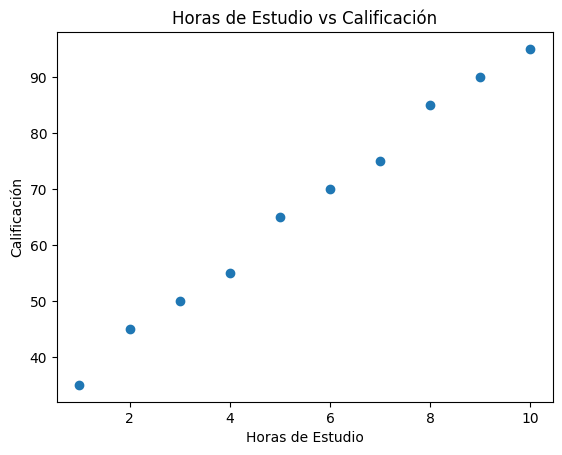

4. Covarianza: 60.8333


In [1]:
# Ejercicio 3: Correlación en Python
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.DataFrame(
    {
        "horas_estudio": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "calificacion": [35, 45, 50, 55, 65, 70, 75, 85, 90, 95],
    }
)

# 1. Calcular correlación
correlacion = df["horas_estudio"].corr(df["calificacion"])
print(f"1. Correlación: {correlacion:.4f}")

# 2. Calcular p-value
r, p_val = stats.pearsonr(df["horas_estudio"], df["calificacion"])
print(f"2. P-value: {p_val:.4e}")

# 3. Scatter plot
plt.scatter(df["horas_estudio"], df["calificacion"])
plt.title("Horas de Estudio vs Calificación")
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificación")
plt.show()

# 4. Calcular covarianza
covarianza = df["horas_estudio"].cov(df["calificacion"])
print(f"4. Covarianza: {covarianza:.4f}")

## Ejercicios de Intervalos de Confianza

**Ejercicio 4: Intervalo de Confianza para la Media**

1. Valor `t` para 95% y 24 gl:

$$
t \approx 2.064
$$

3. Cálculo:

$$ IC = 100 \pm 2.064 \times (15 / 5) = 100 \pm 6.192 $$
$$ IC = [93.808, 106.192] $$

5. Interpretación: Tenemos un 95% de confianza en que la verdadera media poblacional se encuentra entre 93.81 y 106.19.

**Ejercicio 5: Cálculo de p-valor**
1. Estadístico t:
$$
t = \frac{55 - 50}{10 / \sqrt{30}} = \frac{5}{1.825} \approx 2.739
$$
3. p-valor (dos colas, 29 gl):
$$ \approx 0.0104 $$
5. Decisión: Como 0.0104 < 0.05, se **rechaza H0**.

## Ejercicios de Regresión Lineal Simple

**Ejercicio 6: Fórmula de Regresión Lineal**

Usando los datos de `X` e `Y` anteriores `(Cov=1.5, Var(X)=2.5)`:

1. Pendiente:
$$\beta_1 = 1.5 / 2.5 = 0.6 $$

2. Intercepto:
$$ \beta_0 = 4 - (0.6 \times 3) = 4 - 1.8 = 2.2 $$

3. Ecuación:
$$ \hat{y} = 2.2 + 0.6x $$

4. Predicción para `X=6`
$$ \hat{y} = 2.2 + 0.6(6) = 2.2 + 3.6 = 5.8 $$

In [3]:
# Ejercicio 7, 8 y 9: Implementación y Evaluación
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Ejercicio 7
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
y = np.array([2, 4, 5, 4, 5, 6, 7, 8, 9, 11])

modelo = LinearRegression()
modelo.fit(X, y)

print("--- Ejercicio 7 ---")
print(f"Intercepto: {modelo.intercept_:.4f}")
print(f"Pendiente: {modelo.coef_[0]:.4f}")
print(f"Predicción para X=11: {modelo.predict([[11]])[0]:.4f}\n")

# Ejercicio 8
y_real = [1, 2, 3, 4, 5]
y_predicho = [1.1, 2.2, 2.9, 4.1, 4.9]
print("--- Ejercicio 8 ---")
print(f"R² sklearn: {r2_score(y_real, y_predicho):.4f}\n")

# Ejercicio 9
y_real_9 = [10, 20, 30, 40, 50]
y_predicho_9 = [12, 18, 32, 38, 52]
rmse = np.sqrt(mean_squared_error(y_real_9, y_predicho_9))
mae = mean_absolute_error(y_real_9, y_predicho_9)
print("--- Ejercicio 9 ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

--- Ejercicio 7 ---
Intercepto: 1.4000
Pendiente: 0.8545
Predicción para X=11: 10.8000

--- Ejercicio 8 ---
R² sklearn: 0.9920

--- Ejercicio 9 ---
RMSE: 2.0000
MAE: 2.0000


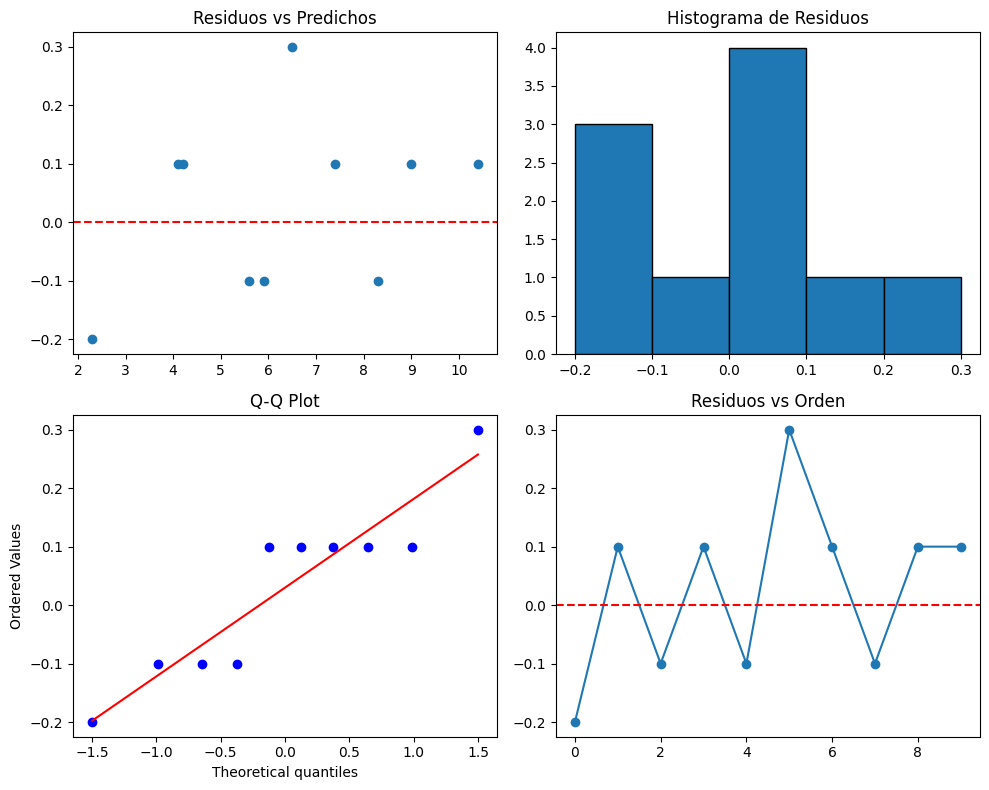

In [4]:
# Ejercicio 10: Análisis de Residuos
import matplotlib.pyplot as plt
import scipy.stats as stats

y_real = np.array([2.1, 4.2, 5.8, 4.3, 5.5, 6.8, 7.5, 8.2, 9.1, 10.5])
y_predicho = np.array([2.3, 4.1, 5.9, 4.2, 5.6, 6.5, 7.4, 8.3, 9.0, 10.4])
residuos = y_real - y_predicho

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# 1. Residuos vs Predichos
axs[0, 0].scatter(y_predicho, residuos)
axs[0, 0].axhline(y=0, color='r', linestyle='--')
axs[0, 0].set_title('Residuos vs Predichos')

# 2. Histograma
axs[0, 1].hist(residuos, bins=5, edgecolor='black')
axs[0, 1].set_title('Histograma de Residuos')

# 3. Q-Q plot
stats.probplot(residuos, dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Q-Q Plot')

# 4. Residuos vs Orden
axs[1, 1].plot(range(len(residuos)), residuos, marker='o')
axs[1, 1].axhline(y=0, color='r', linestyle='--')
axs[1, 1].set_title('Residuos vs Orden')

plt.tight_layout()
plt.show()

In [5]:
# Ejercicio 12: Prueba t para Correlación
from scipy import stats

# Datos
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [2, 4, 5, 4, 5, 6, 7, 8, 9, 11]

# Calcular correlación y p-valor
r, p_value = stats.pearsonr(x, y)

print(f"r: {r:.4f}")
print(f"p-value: {p_value:.4e}")

# Decisión para α = 0.05
if p_value < 0.05:
    print("Rechazar H0: La correlación es significativa")
else:
    print("No rechazar H0: La correlación no es significativa")

r: 0.9635
p-value: 7.4515e-06
Rechazar H0: La correlación es significativa


## Ejercicios Teóricos (11, 13 y 14)

**Ejercicio 11: Supuestos de Regresión**
1. **Linealidad:** La relación entre X e Y debe ser lineal. Se verifica con un diagrama de dispersión de X vs Y o Residuos vs Predichos.
2. **Independencia:** Los residuos no deben estar correlacionados entre sí (autocorrelación). Común en series de tiempo.
3. **Homocedasticidad:** La varianza de los errores es constante. Si es en forma de embudo, hay heterocedasticidad.
4. **Normalidad:** Los residuos deben seguir una distribución normal. El Q-Q plot compara la distribución de los residuos con una distribución normal teórica.

**Ejercicio 13: Aplicaciones de Regresión Lineal**
1. **Regresión a la media:** Fenómeno donde valores extremos en la primera medición tienden a estar más cerca de la media en la segunda.
2. **Negocios:** Predecir ventas basadas en gasto publicitario, estimar demanda según precio.
3. **Correlación vs Causalidad:** Correlación indica asociación; causalidad indica que A provoca B. La regresión mide correlación, no demuestra causalidad por sí sola.

**Ejercicio 14: Limitaciones**
1. **Relaciones no lineales:** Un modelo de línea recta ajustará mal si la relación real es curva o cuadrática.
2. **Extrapolación:** Predecir valores fuera del rango de los datos de entrenamiento. Es riesgoso porque la tendencia podría cambiar fuera de ese rango.
3. **Variable omitida:** Cuando se deja fuera del modelo una variable importante que afecta tanto a X como a Y, sesgando los coeficientes calculados.